# Option C - Data Acquisition and EDA Notebook

**Purpose:** Pull API data and run EDA for Option C (trial site distribution vs disease burden).
Raw data -> `../../product/data/raw/` | Cleaned data -> `../modified_data/`

**Sources**
1. ClinicalTrials.gov v2 API (US type 2 diabetes studies)
2. CDC PLACES (state diabetes age-adjusted prevalence)
3. US Census ACS 5-Year 2022 (state population + poverty)


In [1]:
import json
import os
import pathlib
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import requests
from dotenv import load_dotenv
from sklearn.feature_extraction.text import TfidfVectorizer

DOTENV_PATH = pathlib.Path("../../../.env")
load_dotenv(dotenv_path=DOTENV_PATH)

RAW = pathlib.Path("../../product/data/raw")
MOD = pathlib.Path("../modified_data")
RESULTS = pathlib.Path("../results")
RAW.mkdir(parents=True, exist_ok=True)
MOD.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

CENSUS_KEY = os.getenv("CENSUS_API_KEY", "")

US_STATE_ABBR = {
    "AL", "AK", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "HI", "ID", "IL", "IN", "IA", "KS", "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS", "MO", "MT", "NE", "NV", "NH", "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA", "RI", "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY", "DC"
}

STATE_NAME_TO_ABBR = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "District Of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

FIPS_TO_ABBR = {
    "01": "AL", "02": "AK", "04": "AZ", "05": "AR", "06": "CA", "08": "CO", "09": "CT", "10": "DE", "11": "DC", "12": "FL", "13": "GA", "15": "HI", "16": "ID", "17": "IL", "18": "IN", "19": "IA", "20": "KS", "21": "KY", "22": "LA", "23": "ME", "24": "MD", "25": "MA", "26": "MI", "27": "MN", "28": "MS", "29": "MO", "30": "MT", "31": "NE", "32": "NV", "33": "NH", "34": "NJ", "35": "NM", "36": "NY", "37": "NC", "38": "ND", "39": "OH", "40": "OK", "41": "OR", "42": "PA", "44": "RI", "45": "SC", "46": "SD", "47": "TN", "48": "TX", "49": "UT", "50": "VT", "51": "VA", "53": "WA", "54": "WV", "55": "WI", "56": "WY"
}

# Approximate state tile-grid positions for map-like choropleths without GIS dependencies.
STATE_TILE_POS = {
    "WA": (0, 0), "MT": (1, 0), "ND": (2, 0), "MN": (3, 0), "WI": (4, 0), "MI": (5, 0), "VT": (7, 0), "ME": (8, 0),
    "OR": (0, 1), "ID": (1, 1), "SD": (2, 1), "IA": (3, 1), "IL": (4, 1), "IN": (5, 1), "OH": (6, 1), "PA": (7, 1), "NY": (8, 1),
    "CA": (0, 2), "NV": (1, 2), "WY": (2, 2), "NE": (3, 2), "MO": (4, 2), "KY": (5, 2), "WV": (6, 2), "VA": (7, 2), "MD": (8, 2),
    "AZ": (1, 3), "UT": (2, 3), "CO": (3, 3), "KS": (4, 3), "AR": (5, 3), "TN": (6, 3), "NC": (7, 3), "SC": (8, 3), "DC": (9, 3),
    "NM": (2, 4), "OK": (4, 4), "LA": (5, 4), "MS": (6, 4), "AL": (7, 4), "GA": (8, 4),
    "TX": (4, 5), "FL": (9, 5),
    "AK": (0, 6), "HI": (1, 6),
    "NH": (7, 0), "MA": (8, 0), "CT": (8, 1), "RI": (8, 1), "NJ": (8, 2), "DE": (8, 2)
}


def normalize_state(value):
    if value is None:
        return None
    txt = re.sub(r"\s+", " ", str(value)).strip()
    if not txt:
        return None
    up = txt.upper()
    if up in US_STATE_ABBR:
        return up
    title = txt.title()
    return STATE_NAME_TO_ABBR.get(title)


def phase_group(value):
    if pd.isna(value):
        return "UNKNOWN"
    txt = str(value).strip()
    if not txt:
        return "UNKNOWN"
    parts = [p.strip() for p in txt.split(",") if p.strip()]
    if not parts:
        return "UNKNOWN"
    return parts[0].upper()


def tile_choropleth(df, value_col, title, cmap_name, out_name, vcenter=None):
    val_map = dict(zip(df["stateabbr"], df[value_col]))
    vals = np.array([v for v in val_map.values() if pd.notna(v)])

    if len(vals) == 0:
        print(f"No values available for {value_col}; skipping {title}.")
        return

    if vcenter is None:
        norm = mpl.colors.Normalize(vmin=float(np.nanmin(vals)), vmax=float(np.nanmax(vals)))
    else:
        norm = mpl.colors.TwoSlopeNorm(vmin=float(np.nanmin(vals)), vcenter=vcenter, vmax=float(np.nanmax(vals)))

    cmap = mpl.cm.get_cmap(cmap_name)

    fig, ax = plt.subplots(figsize=(12, 8))
    for st, (x, y) in STATE_TILE_POS.items():
        v = val_map.get(st, np.nan)
        color = "#eeeeee" if pd.isna(v) else cmap(norm(v))
        rect = plt.Rectangle((x, y), 1, 1, facecolor=color, edgecolor="white", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, st, ha="center", va="center", fontsize=8)

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label(value_col)

    out_path = RESULTS / out_name
    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    print("Saved figure:", out_path)


sns.set_theme(style="whitegrid")

print("Raw dir:", RAW.resolve())
print("Modified dir:", MOD.resolve())
print("Results dir:", RESULTS.resolve())
print("Census API key present:", bool(CENSUS_KEY))


Raw dir: D:\OneDrive - University of Toronto\UofT\Year3\Winter\jsc370\JSC370-Midterm-Proj\option-c-trial-access\product\data\raw
Modified dir: D:\OneDrive - University of Toronto\UofT\Year3\Winter\jsc370\JSC370-Midterm-Proj\option-c-trial-access\discover\modified_data
Results dir: D:\OneDrive - University of Toronto\UofT\Year3\Winter\jsc370\JSC370-Midterm-Proj\option-c-trial-access\discover\results
Census API key present: True


---
## 1) ClinicalTrials.gov v2 - US Type 2 Diabetes Studies

Pull pages with cursor pagination and save each page as raw JSON for reproducibility.


In [2]:
version_url = "https://clinicaltrials.gov/api/v2/version"
version_payload = requests.get(version_url, timeout=30).json()
(RAW / "ct_version.json").write_text(json.dumps(version_payload, indent=2), encoding="utf-8")
print("Saved:", RAW / "ct_version.json")
print("Version payload keys:", list(version_payload.keys()))


Saved: ..\..\product\data\raw\ct_version.json
Version payload keys: ['apiVersion', 'dataTimestamp']


In [3]:
ct_url = "https://clinicaltrials.gov/api/v2/studies"

base_params = {
    "query.cond": "type 2 diabetes",
    "query.locn": "United States",
    "pageSize": 1000,
    "countTotal": "true",
}

page_token = None
page_num = 0
total_studies = 0

while True:
    page_params = dict(base_params)
    if page_token:
        page_params["pageToken"] = page_token

    resp = requests.get(ct_url, params=page_params, timeout=60)
    resp.raise_for_status()
    payload = resp.json()
    studies = payload.get("studies", [])

    if not studies:
        print("No studies returned; stopping.")
        break

    out = RAW / f"ct_diabetes_studies_page{page_num}.json"
    out.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    total_studies += len(studies)
    print(f"Saved page {page_num}: {len(studies)} studies -> {out.name}")

    page_token = payload.get("nextPageToken")
    if not page_token:
        break

    page_num += 1
    time.sleep(0.2)

print("Done. Total studies collected:", total_studies)


Saved page 0: 1000 studies -> ct_diabetes_studies_page0.json
Saved page 1: 1000 studies -> ct_diabetes_studies_page1.json
Saved page 2: 1000 studies -> ct_diabetes_studies_page2.json
Saved page 3: 646 studies -> ct_diabetes_studies_page3.json
Done. Total studies collected: 3646


In [4]:
page_files = sorted(RAW.glob("ct_diabetes_studies_page*.json"))
if not page_files:
    raise FileNotFoundError("No ClinicalTrials.gov page files found. Run the fetch cell first.")

trial_rows = []
site_rows = []

for page in page_files:
    payload = json.loads(page.read_text(encoding="utf-8"))
    for study in payload.get("studies", []):
        protocol = study.get("protocolSection", {})
        ident_mod = protocol.get("identificationModule", {})
        status_mod = protocol.get("statusModule", {})
        design_mod = protocol.get("designModule", {})
        sponsor_mod = protocol.get("sponsorCollaboratorsModule", {})
        contacts_mod = protocol.get("contactsLocationsModule", {})

        nct_id = ident_mod.get("nctId")
        if not nct_id:
            continue

        title = ident_mod.get("officialTitle") or ident_mod.get("briefTitle") or ""
        lead_sponsor = sponsor_mod.get("leadSponsor", {}) if isinstance(sponsor_mod, dict) else {}
        sponsor_class = str(lead_sponsor.get("class", "")).upper()
        is_industry = 1 if sponsor_class == "INDUSTRY" else 0

        phases = design_mod.get("phases", [])
        phase_text = ", ".join(phases) if isinstance(phases, list) else str(phases)

        trial_rows.append(
            {
                "nct_id": nct_id,
                "official_title": title,
                "overall_status": status_mod.get("overallStatus"),
                "phase": phase_text,
                "lead_sponsor_class": sponsor_class,
                "is_industry": is_industry,
            }
        )

        locations = contacts_mod.get("locations", []) if isinstance(contacts_mod, dict) else []
        if not isinstance(locations, list):
            locations = []

        for loc in locations:
            country = str(loc.get("country", "")).strip().upper()
            state_abbr = normalize_state(loc.get("state"))
            if country and country not in {"UNITED STATES", "US", "USA"}:
                continue
            site_rows.append(
                {
                    "nct_id": nct_id,
                    "state": state_abbr,
                    "state_raw": loc.get("state"),
                    "country": country,
                    "facility": loc.get("facility"),
                    "city": loc.get("city"),
                }
            )

df_trials = pd.DataFrame(trial_rows).drop_duplicates(subset=["nct_id"]).copy()
df_sites = pd.DataFrame(site_rows)
df_sites_us = df_sites.dropna(subset=["nct_id", "state"]).copy()
df_sites_us = df_sites_us[df_sites_us["state"].isin(US_STATE_ABBR)].copy()
df_sites_unique = df_sites_us.drop_duplicates(subset=["nct_id", "state"]).copy()

state_trial_count = (
    df_sites_unique.groupby("state", as_index=False)["nct_id"]
    .nunique()
    .rename(columns={"state": "stateabbr", "nct_id": "trial_count"})
)
state_site_count = (
    df_sites_us.groupby("state", as_index=False)
    .size()
    .rename(columns={"state": "stateabbr", "size": "site_count"})
)

df_state_ct = (
    pd.DataFrame({"stateabbr": sorted(US_STATE_ABBR)})
    .merge(state_trial_count, on="stateabbr", how="left")
    .merge(state_site_count, on="stateabbr", how="left")
)

for c in ["trial_count", "site_count"]:
    df_state_ct[c] = df_state_ct[c].fillna(0).astype(int)

# State-trial pairs with metadata for sponsor/phase/status stratified summaries.
df_trial_state = (
    df_sites_unique.rename(columns={"state": "stateabbr"})[["nct_id", "stateabbr"]]
    .drop_duplicates()
    .merge(
        df_trials[["nct_id", "is_industry", "lead_sponsor_class", "overall_status", "phase"]],
        on="nct_id",
        how="left",
    )
)

df_trial_state["sponsor_group"] = np.where(df_trial_state["is_industry"] == 1, "INDUSTRY", "NON_INDUSTRY")
df_trial_state["status_group"] = df_trial_state["overall_status"].fillna("UNKNOWN").astype(str).str.upper()
df_trial_state["phase_group"] = df_trial_state["phase"].apply(phase_group)

df_trials.to_csv(MOD / "ct_trials_flat.csv", index=False)
df_sites_us.to_csv(MOD / "ct_sites_flat.csv", index=False)
df_state_ct.to_csv(MOD / "ct_state_aggregates.csv", index=False)
df_trial_state.to_csv(MOD / "ct_trial_state_pairs.csv", index=False)

print("Trials rows:", len(df_trials))
print("US site rows:", len(df_sites_us))
print("Unique state-trial pairs:", len(df_trial_state))
print("Saved state aggregate:", MOD / "ct_state_aggregates.csv")
df_state_ct.head()


Trials rows: 3646
US site rows: 47116
Unique state-trial pairs: 20406
Saved state aggregate: ..\modified_data\ct_state_aggregates.csv


,stateabbr,trial_count,site_count
0,AK,8,9
1,AL,462,893
2,AR,246,394
3,AZ,527,1159
4,CA,1346,6378


---
## 2) CDC PLACES + ACS 2022

Fetch diabetes burden from CDC PLACES and population denominators from ACS.


In [5]:
cdc_url = "https://data.cdc.gov/resource/swc5-untb.json"
offset = 0
limit = 10000
cdc_rows = []

while True:
    cdc_params = {
        "$where": "measureid='DIABETES' AND datavaluetypeid='AgeAdjPrv'",
        "$limit": limit,
        "$offset": offset,
        "$order": "locationid",
    }
    chunk = requests.get(cdc_url, params=cdc_params, timeout=60).json()
    if not chunk:
        break
    cdc_rows.extend(chunk)
    print(f"CDC rows fetched: {len(cdc_rows)}")
    if len(chunk) < limit:
        break
    offset += limit
    time.sleep(0.2)

(RAW / "cdc_places_diabetes_state.json").write_text(json.dumps(cdc_rows, indent=2), encoding="utf-8")

df_cdc = pd.DataFrame(cdc_rows)
if df_cdc.empty:
    raise ValueError("CDC PLACES API returned no rows for DIABETES + AgeAdjPrv.")

df_cdc.columns = [c.lower() for c in df_cdc.columns]
state_col = "stateabbr" if "stateabbr" in df_cdc.columns else ("locationabbr" if "locationabbr" in df_cdc.columns else None)
year_col = "year" if "year" in df_cdc.columns else None
val_col = "data_value" if "data_value" in df_cdc.columns else ("datavalue" if "datavalue" in df_cdc.columns else None)
low_col = "low_confidence_limit" if "low_confidence_limit" in df_cdc.columns else None
high_col = "high_confidence_limit" if "high_confidence_limit" in df_cdc.columns else None

if not state_col or not year_col or not val_col:
    raise KeyError(f"Unexpected CDC columns: {df_cdc.columns.tolist()}")

df_cdc["stateabbr"] = df_cdc[state_col].astype(str).str.upper()
df_cdc[year_col] = pd.to_numeric(df_cdc[year_col], errors="coerce")
df_cdc[val_col] = pd.to_numeric(df_cdc[val_col], errors="coerce")
if low_col:
    df_cdc[low_col] = pd.to_numeric(df_cdc[low_col], errors="coerce")
if high_col:
    df_cdc[high_col] = pd.to_numeric(df_cdc[high_col], errors="coerce")

df_cdc = df_cdc[df_cdc["stateabbr"].isin(US_STATE_ABBR)].copy()
df_cdc_latest = (
    df_cdc.sort_values(["stateabbr", year_col])
    .groupby("stateabbr", as_index=False)
    .tail(1)
    .rename(columns={year_col: "year", val_col: "diabetes_prevalence"})
)

if low_col:
    df_cdc_latest = df_cdc_latest.rename(columns={low_col: "diabetes_low_ci"})
else:
    df_cdc_latest["diabetes_low_ci"] = np.nan

if high_col:
    df_cdc_latest = df_cdc_latest.rename(columns={high_col: "diabetes_high_ci"})
else:
    df_cdc_latest["diabetes_high_ci"] = np.nan

df_cdc_latest = df_cdc_latest[["stateabbr", "year", "diabetes_prevalence", "diabetes_low_ci", "diabetes_high_ci"]]
df_cdc_latest.to_csv(MOD / "cdc_diabetes_state_latest.csv", index=False)

print("Saved CDC latest-year state table:", MOD / "cdc_diabetes_state_latest.csv")
df_cdc_latest.head()


CDC rows fetched: 2958
Saved CDC latest-year state table: ..\modified_data\cdc_diabetes_state_latest.csv


,stateabbr,year,diabetes_prevalence,diabetes_low_ci,diabetes_high_ci
96,AK,2023,13.9,12.1,15.9
66,AL,2023,12.7,10.9,14.6
186,AR,2023,12.2,10.5,14.1
111,AZ,2023,12.9,11.2,14.8
244,CA,2023,11.0,9.5,12.7


In [6]:
acs_url = "https://api.census.gov/data/2022/acs/acs5"
acs_vars = ["B01003_001E", "B17001_001E", "B17001_002E"]

acs_params = {
    "get": ",".join(acs_vars),
    "for": "state:*",
}
if CENSUS_KEY:
    acs_params["key"] = CENSUS_KEY

acs_payload = requests.get(acs_url, params=acs_params, timeout=60).json()
(RAW / "acs_state_2022.json").write_text(json.dumps(acs_payload, indent=2), encoding="utf-8")

if not acs_payload or len(acs_payload) < 2:
    raise ValueError("ACS API returned empty payload.")

acs_header = acs_payload[0]
acs_rows = acs_payload[1:]
df_acs = pd.DataFrame(acs_rows, columns=acs_header)

for col in ["B01003_001E", "B17001_001E", "B17001_002E"]:
    df_acs[col] = pd.to_numeric(df_acs[col], errors="coerce")

df_acs["stateabbr"] = df_acs["state"].map(FIPS_TO_ABBR)
df_acs["population"] = df_acs["B01003_001E"]
df_acs["poverty_rate"] = np.where(
    df_acs["B17001_001E"] > 0,
    100.0 * df_acs["B17001_002E"] / df_acs["B17001_001E"],
    np.nan,
)

df_acs_features = df_acs[["stateabbr", "population", "poverty_rate"]].copy()
df_acs_features = df_acs_features[df_acs_features["stateabbr"].isin(US_STATE_ABBR)].copy()
df_acs_features.to_csv(MOD / "acs_state_2022_features.csv", index=False)

print("Saved ACS features:", MOD / "acs_state_2022_features.csv")
df_acs_features.head()


Saved ACS features: ..\modified_data\acs_state_2022_features.csv


,stateabbr,population,poverty_rate
0,AL,5028092,15.722492
1,AK,734821,10.487625
2,AZ,7172282,13.065051
3,AR,3018669,16.228858
4,CA,39356104,12.124320


---
## 3) Feature Construction and EDA

Construct state-level site-density metrics, stratified summaries, and empirical coverage residuals.


In [7]:
df_final = (
    pd.DataFrame({"stateabbr": sorted(US_STATE_ABBR)})
    .merge(df_state_ct, on="stateabbr", how="left")
    .merge(df_cdc_latest, on="stateabbr", how="left")
    .merge(df_acs_features, on="stateabbr", how="left")
)

for col in ["trial_count", "site_count"]:
    df_final[col] = df_final[col].fillna(0).astype(int)

denom = df_final["population"] / 100000.0
df_final["trials_per_100k"] = np.where(denom > 0, df_final["trial_count"] / denom, np.nan)

# Sponsor/status/phase densities from state-trial pairs.
state_sponsor = (
    df_trial_state.groupby(["stateabbr", "sponsor_group"], as_index=False)["nct_id"]
    .nunique()
    .rename(columns={"nct_id": "trial_count"})
)
state_sponsor = state_sponsor.merge(df_acs_features[["stateabbr", "population"]], on="stateabbr", how="left")
state_sponsor["trials_per_100k"] = np.where(
    state_sponsor["population"] > 0,
    state_sponsor["trial_count"] / (state_sponsor["population"] / 100000.0),
    np.nan,
)

state_status = (
    df_trial_state.groupby(["stateabbr", "status_group"], as_index=False)["nct_id"]
    .nunique()
    .rename(columns={"nct_id": "trial_count"})
)
state_status = state_status.merge(df_acs_features[["stateabbr", "population"]], on="stateabbr", how="left")
state_status["trials_per_100k"] = np.where(
    state_status["population"] > 0,
    state_status["trial_count"] / (state_status["population"] / 100000.0),
    np.nan,
)

state_phase = (
    df_trial_state.groupby(["stateabbr", "phase_group"], as_index=False)["nct_id"]
    .nunique()
    .rename(columns={"nct_id": "trial_count"})
)
state_phase = state_phase.merge(df_acs_features[["stateabbr", "population"]], on="stateabbr", how="left")
state_phase["trials_per_100k"] = np.where(
    state_phase["population"] > 0,
    state_phase["trial_count"] / (state_phase["population"] / 100000.0),
    np.nan,
)

industry_counts = (
    state_sponsor[state_sponsor["sponsor_group"] == "INDUSTRY"]
    [["stateabbr", "trial_count"]]
    .rename(columns={"trial_count": "industry_trial_count"})
)
non_industry_counts = (
    state_sponsor[state_sponsor["sponsor_group"] == "NON_INDUSTRY"]
    [["stateabbr", "trial_count"]]
    .rename(columns={"trial_count": "non_industry_trial_count"})
)

df_final = df_final.merge(industry_counts, on="stateabbr", how="left").merge(non_industry_counts, on="stateabbr", how="left")
df_final["industry_trial_count"] = df_final["industry_trial_count"].fillna(0).astype(int)
df_final["non_industry_trial_count"] = df_final["non_industry_trial_count"].fillna(0).astype(int)
df_final["industry_trials_per_100k"] = np.where(denom > 0, df_final["industry_trial_count"] / denom, np.nan)
df_final["non_industry_trials_per_100k"] = np.where(denom > 0, df_final["non_industry_trial_count"] / denom, np.nan)
df_final["industry_pct"] = np.where(df_final["trial_count"] > 0, 100.0 * df_final["industry_trial_count"] / df_final["trial_count"], np.nan)

# Empirical expected-density baseline from burden deciles.
df_final["burden_decile"] = pd.qcut(df_final["diabetes_prevalence"], q=10, labels=False, duplicates="drop")
df_final["burden_decile"] = df_final["burden_decile"].astype("float") + 1.0
df_final["expected_trials_per_100k"] = df_final.groupby("burden_decile")["trials_per_100k"].transform("mean")
df_final["coverage_residual"] = df_final["trials_per_100k"] - df_final["expected_trials_per_100k"]

resid_std = df_final["coverage_residual"].std(skipna=True)
if resid_std and not np.isnan(resid_std) and resid_std > 0:
    resid_mean = df_final["coverage_residual"].mean(skipna=True)
    df_final["coverage_residual_z"] = (df_final["coverage_residual"] - resid_mean) / resid_std
else:
    df_final["coverage_residual_z"] = np.nan

df_final["coverage_quartile"] = pd.qcut(
    df_final["coverage_residual"],
    q=4,
    labels=["Q1_low", "Q2", "Q3", "Q4_high"],
    duplicates="drop",
)

# Persist outputs.
df_final.to_csv(MOD / "state_coverage_alignment.csv", index=False)
state_sponsor.to_csv(MOD / "state_density_by_sponsor.csv", index=False)
state_status.to_csv(MOD / "state_density_by_status.csv", index=False)
state_phase.to_csv(MOD / "state_density_by_phase.csv", index=False)

print("Saved:", MOD / "state_coverage_alignment.csv")
print("Saved:", MOD / "state_density_by_sponsor.csv")
print("Saved:", MOD / "state_density_by_status.csv")
print("Saved:", MOD / "state_density_by_phase.csv")

df_final.sort_values("coverage_residual", ascending=True).head(10)


Saved: ..\modified_data\state_coverage_alignment.csv
Saved: ..\modified_data\state_density_by_sponsor.csv
Saved: ..\modified_data\state_density_by_status.csv
Saved: ..\modified_data\state_density_by_phase.csv


,stateabbr,trial_count,site_count,year,diabetes_prevalence,diabetes_low_ci,diabetes_high_ci,population,poverty_rate,trials_per_100k,industry_trial_count,non_industry_trial_count,industry_trials_per_100k,non_industry_trials_per_100k,industry_pct,burden_decile,expected_trials_per_100k,coverage_residual,coverage_residual_z,coverage_quartile
34,NY,790,1692,2023.0,8.9,7.6,10.4,19994379,13.606940,3.951110,614,176,3.070863,0.880247,77.721519,2.0,10.380290,-6.429179,-1.859794,Q1_low
50,WY,1,1,2023.0,9.7,8.3,11.3,577929,10.660072,0.173032,0,1,0.000000,0.173032,0.000000,4.0,6.284430,-6.111398,-1.767868,Q1_low
0,AK,8,9,2023.0,13.9,12.1,15.9,734821,10.487625,1.088701,7,1,0.952613,0.136088,87.500000,9.0,6.962172,-5.873471,-1.699042,Q1_low
14,IL,636,1167,2023.0,8.6,7.2,10.0,12757634,11.763222,4.985250,546,90,4.279790,0.705460,85.849057,2.0,10.380290,-5.395039,-1.560644,Q1_low
22,MI,472,895,2023.0,10.3,8.7,11.9,10057921,13.134913,4.692819,406,66,4.036619,0.656199,86.016949,6.0,9.835423,-5.142604,-1.487621,Q1_low
19,MA,500,674,2023.0,9.0,7.7,10.2,6984205,9.928116,7.159011,327,173,4.681993,2.477018,65.400000,3.0,11.210650,-4.051639,-1.172033,Q1_low
5,CO,457,684,2023.0,9.2,7.8,10.8,5770790,9.553819,7.919193,369,88,6.394272,1.524921,80.743982,3.0,11.210650,-3.291457,-0.952133,Q1_low
30,NH,98,103,2023.0,8.4,7.2,9.7,1379610,7.325118,7.103457,95,3,6.886004,0.217453,96.938776,2.0,10.380290,-3.276833,-0.947902,Q1_low
31,NJ,437,716,2023.0,8.0,6.8,9.3,9249063,9.681402,4.724803,411,26,4.443693,0.281110,94.050343,1.0,7.997941,-3.273138,-0.946834,Q1_low
4,CA,1346,6378,2023.0,11.0,9.5,12.7,39356104,12.124320,3.420054,1087,259,2.761960,0.658094,80.757801,7.0,6.399334,-2.979280,-0.861828,Q1_low


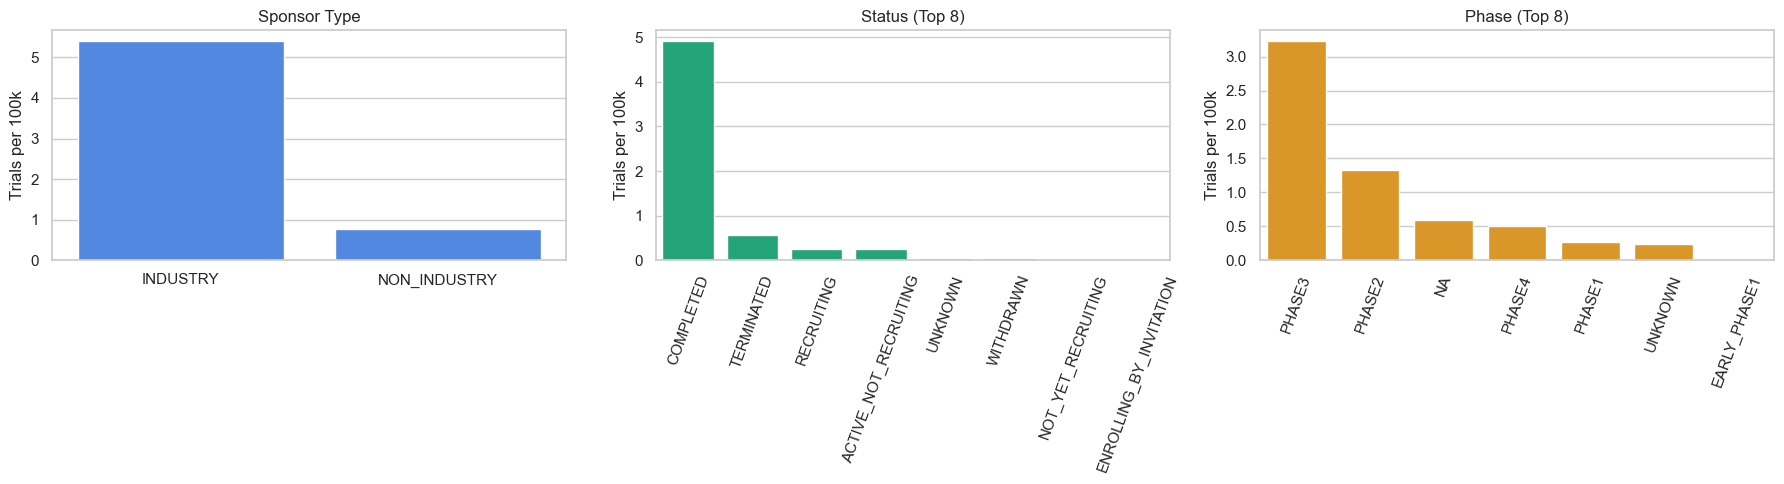

Saved figure: ..\results\density_by_sponsor_phase_status.png


In [8]:
# National-level density snapshots by sponsor/phase/status from state tables.
def national_density(df, group_col):
    tmp = df.groupby(group_col, as_index=False).agg(
        trial_count=("trial_count", "sum"),
        population=("population", "sum"),
    )
    tmp["trials_per_100k"] = np.where(
        tmp["population"] > 0,
        tmp["trial_count"] / (tmp["population"] / 100000.0),
        np.nan,
    )
    return tmp.sort_values("trials_per_100k", ascending=False)

nat_sponsor = national_density(state_sponsor, "sponsor_group")
nat_status = national_density(state_status, "status_group")
nat_phase = national_density(state_phase, "phase_group")

nat_sponsor.to_csv(MOD / "national_density_by_sponsor.csv", index=False)
nat_status.to_csv(MOD / "national_density_by_status.csv", index=False)
nat_phase.to_csv(MOD / "national_density_by_phase.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=nat_sponsor, x="sponsor_group", y="trials_per_100k", ax=axes[0], color="#3b82f6")
axes[0].set_title("Sponsor Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Trials per 100k")

status_top = nat_status.head(8)
sns.barplot(data=status_top, x="status_group", y="trials_per_100k", ax=axes[1], color="#10b981")
axes[1].set_title("Status (Top 8)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Trials per 100k")
axes[1].tick_params(axis="x", rotation=70)

phase_top = nat_phase.head(8)
sns.barplot(data=phase_top, x="phase_group", y="trials_per_100k", ax=axes[2], color="#f59e0b")
axes[2].set_title("Phase (Top 8)")
axes[2].set_xlabel("")
axes[2].set_ylabel("Trials per 100k")
axes[2].tick_params(axis="x", rotation=70)

fig.tight_layout()
fig.savefig(RESULTS / "density_by_sponsor_phase_status.png", dpi=200)
plt.show()
print("Saved figure:", RESULTS / "density_by_sponsor_phase_status.png")


In [9]:
df_desc = df_final.copy()

def format_ci(row):
    if pd.notna(row["diabetes_prevalence"]) and pd.notna(row["diabetes_low_ci"]) and pd.notna(row["diabetes_high_ci"]):
        return f"{row['diabetes_prevalence']:.2f} ({row['diabetes_low_ci']:.2f}, {row['diabetes_high_ci']:.2f})"
    if pd.notna(row["diabetes_prevalence"]):
        return f"{row['diabetes_prevalence']:.2f}"
    return np.nan

df_desc["diabetes_prev_ci"] = df_desc.apply(format_ci, axis=1)

under_states = set(df_desc.nsmallest(10, "coverage_residual")["stateabbr"])
over_states = set(df_desc.nlargest(10, "coverage_residual")["stateabbr"])
df_desc["coverage_flag"] = np.select(
    [df_desc["stateabbr"].isin(under_states), df_desc["stateabbr"].isin(over_states)],
    ["Top 10 under-covered", "Top 10 over-covered"],
    default="",
)

display_cols = [
    "stateabbr",
    "diabetes_prev_ci",
    "trial_count",
    "site_count",
    "trials_per_100k",
    "expected_trials_per_100k",
    "coverage_residual",
    "industry_pct",
    "coverage_flag",
]

df_desc_out = df_desc[display_cols].sort_values("coverage_residual")
df_desc_out.to_csv(MOD / "state_coverage_descriptive_table.csv", index=False)
print("Saved:", MOD / "state_coverage_descriptive_table.csv")
df_desc_out.head(20)


Saved: ..\modified_data\state_coverage_descriptive_table.csv


,stateabbr,diabetes_prev_ci,trial_count,site_count,trials_per_100k,expected_trials_per_100k,coverage_residual,industry_pct,coverage_flag
34,NY,"8.90 (7.60, 10.40)",790,1692,3.951110,10.380290,-6.429179,77.721519,Top 10 under-covered
50,WY,"9.70 (8.30, 11.30)",1,1,0.173032,6.284430,-6.111398,0.000000,Top 10 under-covered
0,AK,"13.90 (12.10, 15.90)",8,9,1.088701,6.962172,-5.873471,87.500000,Top 10 under-covered
14,IL,"8.60 (7.20, 10.00)",636,1167,4.985250,10.380290,-5.395039,85.849057,Top 10 under-covered
22,MI,"10.30 (8.70, 11.90)",472,895,4.692819,9.835423,-5.142604,86.016949,Top 10 under-covered
19,MA,"9.00 (7.70, 10.20)",500,674,7.159011,11.210650,-4.051639,65.400000,Top 10 under-covered
5,CO,"9.20 (7.80, 10.80)",457,684,7.919193,11.210650,-3.291457,80.743982,Top 10 under-covered
30,NH,"8.40 (7.20, 9.70)",98,103,7.103457,10.380290,-3.276833,96.938776,Top 10 under-covered
31,NJ,"8.00 (6.80, 9.30)",437,716,4.724803,7.997941,-3.273138,94.050343,Top 10 under-covered
4,CA,"11.00 (9.50, 12.70)",1346,6378,3.420054,6.399334,-2.979280,80.757801,Top 10 under-covered


C:\Users\user\AppData\Local\Temp\ipykernel_44512\3839186943.py:91: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)


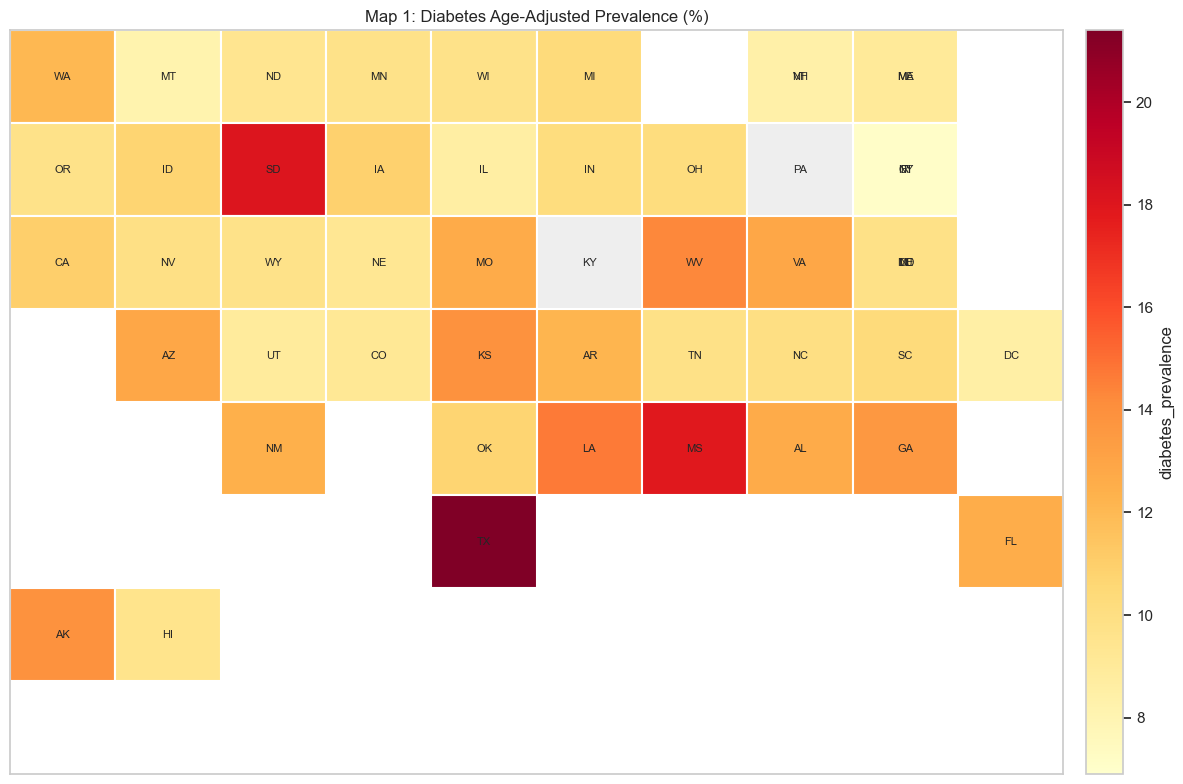

Saved figure: ..\results\map_diabetes_prevalence_tile.png


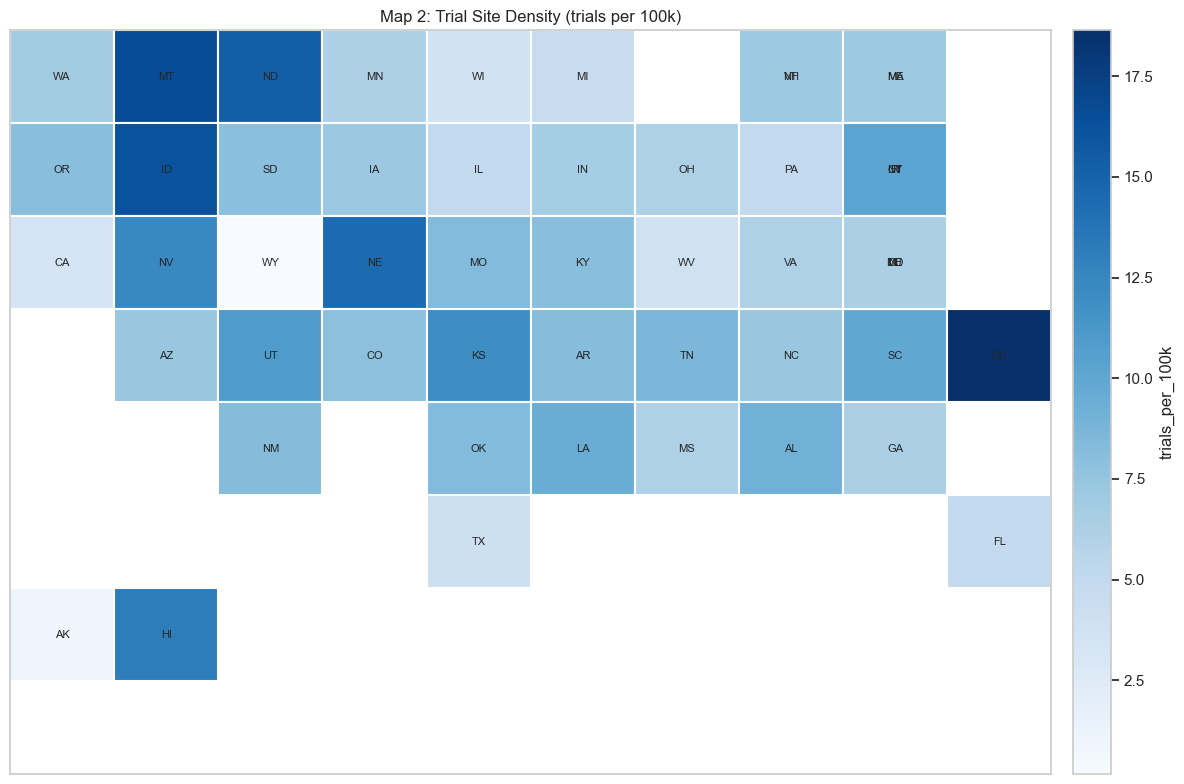

Saved figure: ..\results\map_trial_density_tile.png


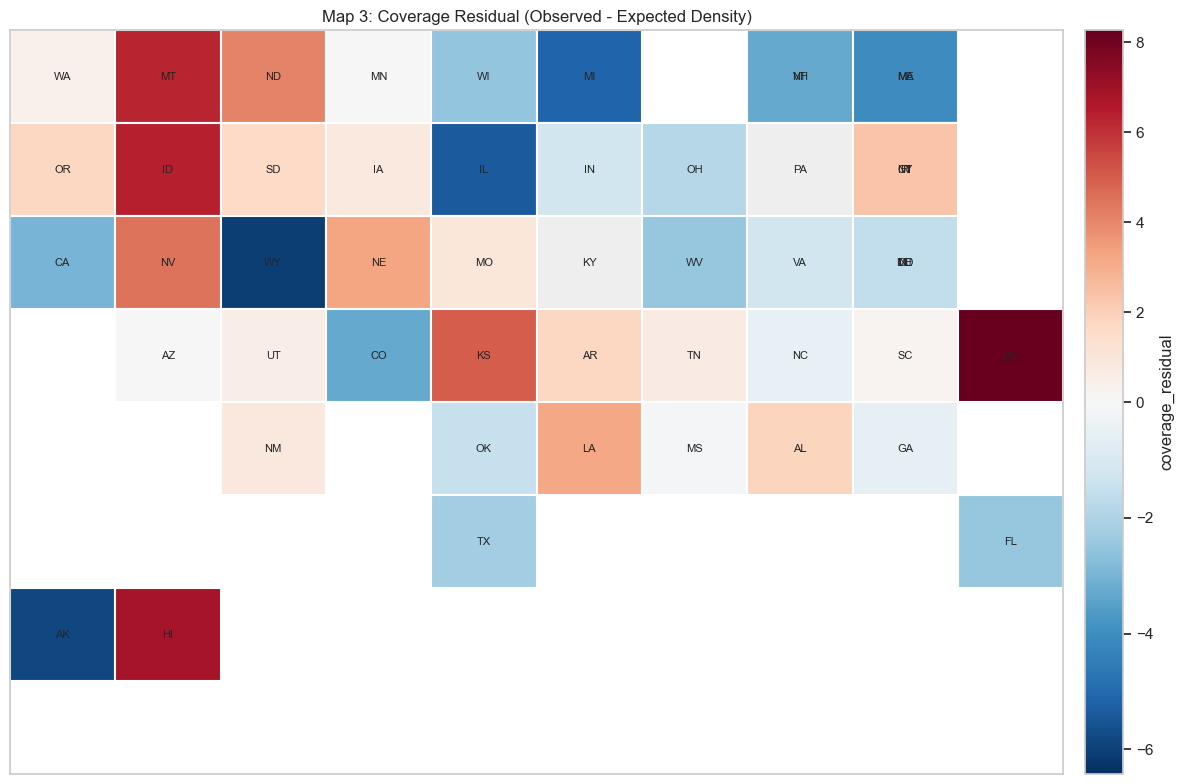

Saved figure: ..\results\map_coverage_residual_tile.png


In [10]:
tile_choropleth(
    df_final,
    value_col="diabetes_prevalence",
    title="Map 1: Diabetes Age-Adjusted Prevalence (%)",
    cmap_name="YlOrRd",
    out_name="map_diabetes_prevalence_tile.png",
)

tile_choropleth(
    df_final,
    value_col="trials_per_100k",
    title="Map 2: Trial Site Density (trials per 100k)",
    cmap_name="Blues",
    out_name="map_trial_density_tile.png",
)

tile_choropleth(
    df_final,
    value_col="coverage_residual",
    title="Map 3: Coverage Residual (Observed - Expected Density)",
    cmap_name="RdBu_r",
    out_name="map_coverage_residual_tile.png",
    vcenter=0.0,
)


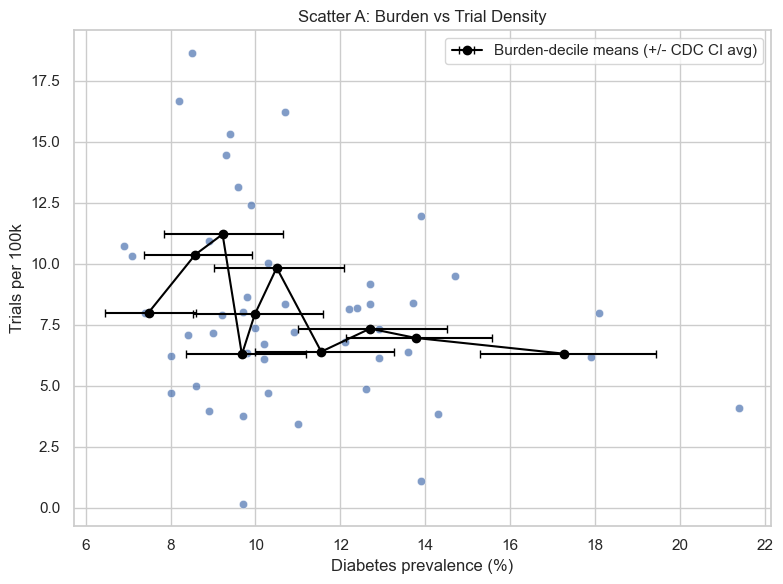

Saved figure: ..\results\scatter_burden_vs_density_binned.png


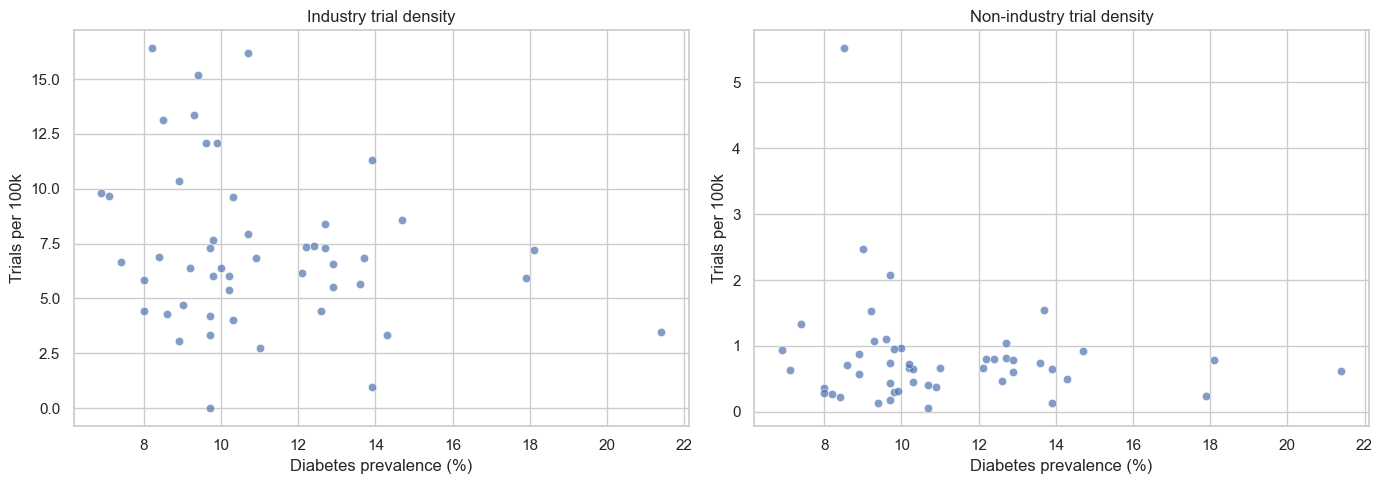

Saved figure: ..\results\scatter_industry_vs_non_industry_density.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter_df = df_final.dropna(subset=["diabetes_prevalence", "trials_per_100k"]).copy()
sns.scatterplot(data=scatter_df, x="diabetes_prevalence", y="trials_per_100k", ax=ax, alpha=0.7)

binned = (
    scatter_df.dropna(subset=["burden_decile"])
    .groupby("burden_decile", as_index=False)
    .agg(
        mean_prev=("diabetes_prevalence", "mean"),
        mean_density=("trials_per_100k", "mean"),
        mean_low_ci=("diabetes_low_ci", "mean"),
        mean_high_ci=("diabetes_high_ci", "mean"),
    )
)

xerr_left = np.clip(binned["mean_prev"] - binned["mean_low_ci"], a_min=0, a_max=None)
xerr_right = np.clip(binned["mean_high_ci"] - binned["mean_prev"], a_min=0, a_max=None)

ax.errorbar(
    x=binned["mean_prev"],
    y=binned["mean_density"],
    xerr=[xerr_left, xerr_right],
    fmt="o-",
    color="black",
    linewidth=1.5,
    capsize=3,
    label="Burden-decile means (+/- CDC CI avg)",
)

ax.set_title("Scatter A: Burden vs Trial Density")
ax.set_xlabel("Diabetes prevalence (%)")
ax.set_ylabel("Trials per 100k")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(RESULTS / "scatter_burden_vs_density_binned.png", dpi=200)
plt.show()
print("Saved figure:", RESULTS / "scatter_burden_vs_density_binned.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.scatterplot(data=df_final, x="diabetes_prevalence", y="industry_trials_per_100k", ax=axes[0], alpha=0.7)
sns.scatterplot(data=df_final, x="diabetes_prevalence", y="non_industry_trials_per_100k", ax=axes[1], alpha=0.7)

axes[0].set_title("Industry trial density")
axes[1].set_title("Non-industry trial density")
axes[0].set_xlabel("Diabetes prevalence (%)")
axes[1].set_xlabel("Diabetes prevalence (%)")
axes[0].set_ylabel("Trials per 100k")
axes[1].set_ylabel("Trials per 100k")

fig.tight_layout()
fig.savefig(RESULTS / "scatter_industry_vs_non_industry_density.png", dpi=200)
plt.show()
print("Saved figure:", RESULTS / "scatter_industry_vs_non_industry_density.png")


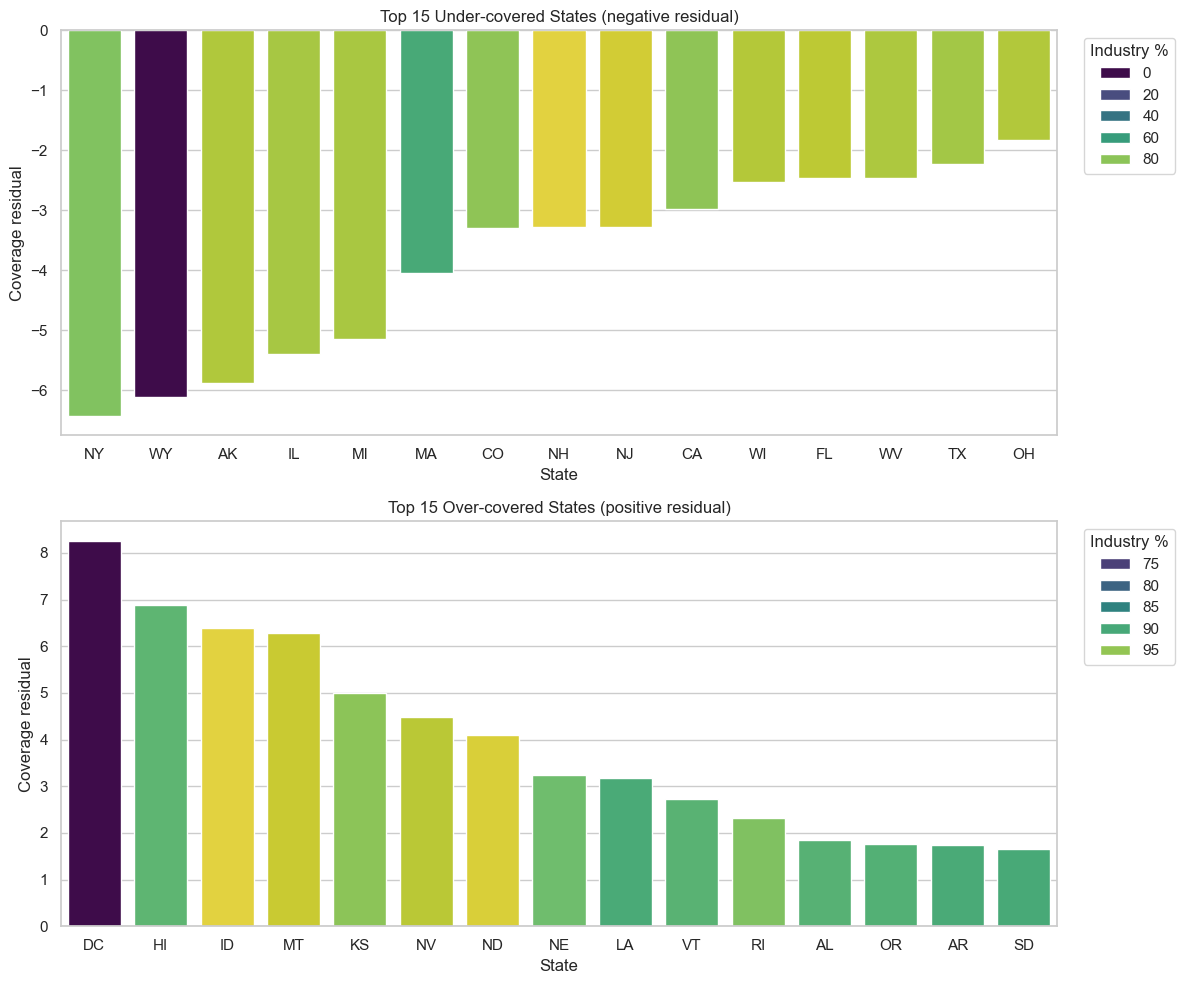

Saved figure: ..\results\coverage_residual_outlier_bars.png
Saved: ..\modified_data\trial_title_tfidf_top_terms.csv
Saved: ..\modified_data\trial_category_by_coverage_quartile.csv


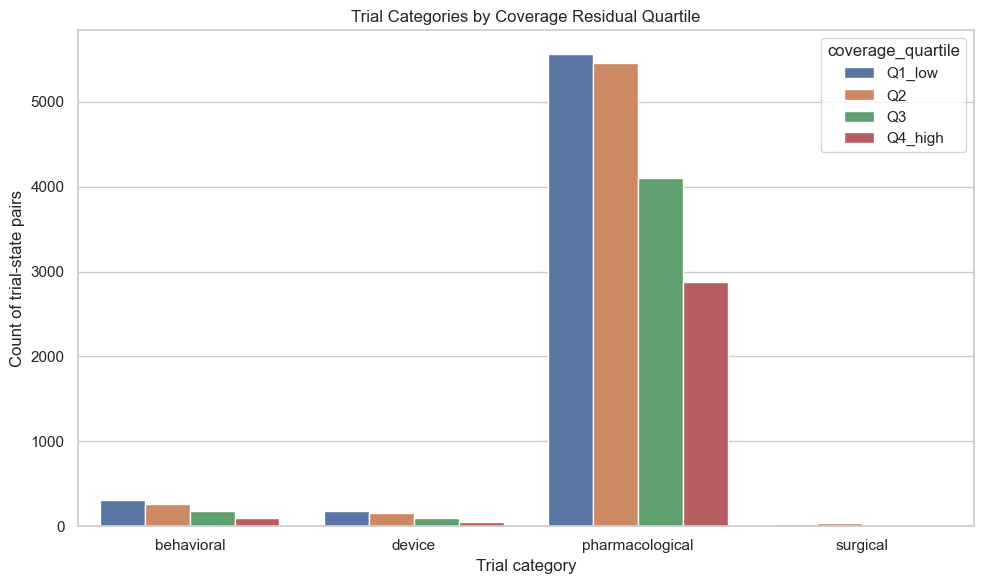

Saved figure: ..\results\trial_category_by_coverage_quartile_bar.png


In [12]:
under = df_final.nsmallest(15, "coverage_residual").copy()
over = df_final.nlargest(15, "coverage_residual").copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sns.barplot(data=under, x="stateabbr", y="coverage_residual", hue="industry_pct", palette="viridis", ax=axes[0], dodge=False)
axes[0].set_title("Top 15 Under-covered States (negative residual)")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Coverage residual")
axes[0].legend(title="Industry %", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(data=over, x="stateabbr", y="coverage_residual", hue="industry_pct", palette="viridis", ax=axes[1], dodge=False)
axes[1].set_title("Top 15 Over-covered States (positive residual)")
axes[1].set_xlabel("State")
axes[1].set_ylabel("Coverage residual")
axes[1].legend(title="Industry %", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
fig.savefig(RESULTS / "coverage_residual_outlier_bars.png", dpi=200)
plt.show()
print("Saved figure:", RESULTS / "coverage_residual_outlier_bars.png")


titles = df_trials["official_title"].fillna("").astype(str).str.strip()
titles = titles[titles != ""]

if len(titles) > 0:
    tfidf = TfidfVectorizer(max_features=500, stop_words="english")
    X = tfidf.fit_transform(titles)
    terms = tfidf.get_feature_names_out()
    mean_scores = np.asarray(X.mean(axis=0)).ravel()
    df_tfidf = (
        pd.DataFrame({"term": terms, "mean_tfidf": mean_scores})
        .sort_values("mean_tfidf", ascending=False)
        .head(30)
        .reset_index(drop=True)
    )
else:
    df_tfidf = pd.DataFrame(columns=["term", "mean_tfidf"])

df_tfidf.to_csv(MOD / "trial_title_tfidf_top_terms.csv", index=False)
print("Saved:", MOD / "trial_title_tfidf_top_terms.csv")

def classify_trial(title):
    t = str(title).lower()
    if any(w in t for w in ["surgery", "bariatric", "transplant", "resection"]):
        return "surgical"
    if any(w in t for w in ["device", "monitor", "sensor", "pump", "wearable", "cgm"]):
        return "device"
    if any(w in t for w in ["lifestyle", "exercise", "diet", "nutrition", "education", "behavioral", "behaviour"]):
        return "behavioral"
    return "pharmacological"

df_trials["trial_category"] = df_trials["official_title"].apply(classify_trial)

df_topic_geo = df_trial_state.merge(
    df_final[["stateabbr", "coverage_quartile"]],
    on="stateabbr",
    how="left",
).merge(df_trials[["nct_id", "trial_category"]], on="nct_id", how="left")

df_cat = (
    df_topic_geo.dropna(subset=["coverage_quartile", "trial_category"])
    .groupby(["coverage_quartile", "trial_category"], as_index=False)
    .size()
    .rename(columns={"size": "trial_state_pairs"})
)

df_cat.to_csv(MOD / "trial_category_by_coverage_quartile.csv", index=False)
print("Saved:", MOD / "trial_category_by_coverage_quartile.csv")

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=df_cat, x="trial_category", y="trial_state_pairs", hue="coverage_quartile", ax=ax)
ax.set_title("Trial Categories by Coverage Residual Quartile")
ax.set_xlabel("Trial category")
ax.set_ylabel("Count of trial-state pairs")
fig.tight_layout()
fig.savefig(RESULTS / "trial_category_by_coverage_quartile_bar.png", dpi=200)
plt.show()
print("Saved figure:", RESULTS / "trial_category_by_coverage_quartile_bar.png")


In [13]:
summary_paths = [
    MOD / "ct_trials_flat.csv",
    MOD / "ct_sites_flat.csv",
    MOD / "ct_state_aggregates.csv",
    MOD / "ct_trial_state_pairs.csv",
    MOD / "cdc_diabetes_state_latest.csv",
    MOD / "acs_state_2022_features.csv",
    MOD / "state_coverage_alignment.csv",
    MOD / "state_coverage_descriptive_table.csv",
    MOD / "state_density_by_sponsor.csv",
    MOD / "state_density_by_status.csv",
    MOD / "state_density_by_phase.csv",
    MOD / "national_density_by_sponsor.csv",
    MOD / "national_density_by_status.csv",
    MOD / "national_density_by_phase.csv",
    MOD / "trial_title_tfidf_top_terms.csv",
    MOD / "trial_category_by_coverage_quartile.csv",
    RESULTS / "map_diabetes_prevalence_tile.png",
    RESULTS / "map_trial_density_tile.png",
    RESULTS / "map_coverage_residual_tile.png",
    RESULTS / "density_by_sponsor_phase_status.png",
    RESULTS / "scatter_burden_vs_density_binned.png",
    RESULTS / "scatter_industry_vs_non_industry_density.png",
    RESULTS / "coverage_residual_outlier_bars.png",
    RESULTS / "trial_category_by_coverage_quartile_bar.png",
]

for p in summary_paths:
    print(p, "exists:", p.exists())


..\modified_data\ct_trials_flat.csv exists: True
..\modified_data\ct_sites_flat.csv exists: True
..\modified_data\ct_state_aggregates.csv exists: True
..\modified_data\ct_trial_state_pairs.csv exists: True
..\modified_data\cdc_diabetes_state_latest.csv exists: True
..\modified_data\acs_state_2022_features.csv exists: True
..\modified_data\state_coverage_alignment.csv exists: True
..\modified_data\state_coverage_descriptive_table.csv exists: True
..\modified_data\state_density_by_sponsor.csv exists: True
..\modified_data\state_density_by_status.csv exists: True
..\modified_data\state_density_by_phase.csv exists: True
..\modified_data\national_density_by_sponsor.csv exists: True
..\modified_data\national_density_by_status.csv exists: True
..\modified_data\national_density_by_phase.csv exists: True
..\modified_data\trial_title_tfidf_top_terms.csv exists: True
..\modified_data\trial_category_by_coverage_quartile.csv exists: True
..\results\map_diabetes_prevalence_tile.png exists: True
..\r